#Import Data

In [1]:
import zipfile

In [2]:
#import image data from google drive
!gdown --id '1qCHfycy91EyUFzilBvxu8hYVYp0l6jCh' --output Midterm_dataset.zip

/usr/local/lib/python3.9/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1qCHfycy91EyUFzilBvxu8hYVYp0l6jCh
To: /content/Midterm_dataset.zip
100% 50.4M/50.4M [00:01<00:00, 38.3MB/s]


In [3]:
#解壓縮zip檔到temp
local_zip = 'Midterm_dataset.zip'
zip_ref = zipfile.ZipFile(local_zip,'r')

#解壓縮後的目標文件夾(自動創建)
zip_ref.extractall('temp') 
zip_ref.close()

In [4]:
#先回到根目錄再到MidTerm_Dataset資料夾中
%cd /
%cd content/temp/MidTerm_Dataset

/
/content/temp/MidTerm_Dataset


# Import Library

In [5]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os
import pandas as pd 
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle           
import matplotlib.pyplot as plt             
import cv2                                 
import tensorflow as tf                
from tqdm import tqdm
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten, Embedding
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.optimizers import SGD, Adam
from keras.datasets import mnist
from keras.utils import np_utils,to_categorical
from keras.models import Sequential
from keras.optimizers import Adam
import numpy as np 
import pandas as pd 
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Activation, Conv2D, MaxPooling2D,BatchNormalization,GlobalAveragePooling2D
from tqdm import tqdm
from sklearn.utils import shuffle
from tensorflow.keras.utils import load_img,img_to_array
import random
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load Data to program

In [30]:
#Train與Test資料夾中所含有的四個圖片資料夾名稱
class_names = ['bolt','locatingpin','nut','washer']

#設定辨識label-->0:bolt, 1:locatingpin, 2:nut, 3:washer，共有四個標籤
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}
nb_classes = len(class_names)

#設定圖片大小，此處使用224*224，參考為網路各大範例最常出現的值
IMAGE_SIZE = (224, 224)

#將圖片匯入
def load_data():
    #資料夾與輸出
    datasets = ['Train', 'Test']
    output = []
    
    # 透過迴圈進入train and test資料夾
    for dataset in datasets:
        
        images = []
        labels = []
        
        # 列印下載進度，並透過迴圈一次進入一個label的資料夾，並輸入label
        print("Loading {}".format(dataset))
        

        for folder in os.listdir(dataset):
            label = class_names_label[folder]
            
            # 透過迴圈讀取每個資料夾中的所有圖片
            for file in tqdm(os.listdir(os.path.join(dataset, folder))):
                
                # 得到圖片的路徑名稱
                img_path = os.path.join(os.path.join(dataset, folder), file)
                
                # cv讀照片，並resize，且調整原來顏色為RGB，轉為灰階
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)                
                image = cv2.resize(image, IMAGE_SIZE)
                
                # append圖片與其正確的label
                images.append(image)
                labels.append(label)

        # 轉為numpy array的形式，圖片dtype為浮點數，label為整數        
        images = np.array(images, dtype = 'float32')
        labels = np.array(labels, dtype = 'int32')

        #將兩個資料夾的所有資料append起來   
        output.append((images, labels))
    return output


#個別存取training data and testing data
(x_train,y_train),(x_test,y_test) = load_data()

#x_陣列轉換為四維矩陣，dim0:輸入照片總張數, dim1,2:為image_size，dim3:表灰階僅1，若為RGB則為3
x_train = x_train.reshape(x_train.shape[0],224,224,1).astype('float32')
x_test = x_test.reshape(x_test.shape[0],224,224,1).astype('float32')

print("x_train shape: ",x_train.shape)
print("x_test shape: ",x_test.shape)

#標準化－>因為有0-255個色階
x_train = x_train/255
x_test = x_test/255

#將原有的向量轉換為one-hot code，以便進行模型訓練
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

Loading Train


100%|██████████| 1523/1523 [00:00<00:00, 1594.16it/s]


Loading Test


100%|██████████| 381/381 [00:00<00:00, 1408.61it/s]


x_train shape:  (6092, 224, 224, 1)
x_test shape:  (1524, 224, 224, 1)


# Model Building

In [7]:
from tensorflow.keras import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers.experimental import preprocessing

In [ ]:
# #data augumentation資料翻轉
# data_augmentation = keras.Sequential(
#     [
#         #垂直翻轉與水平翻轉
#         tf.keras.layers.experimental.preprocessing.RandomFlip("horizontal"),
#         tf.keras.layers.experimental.preprocessing.RandomFlip("vertical"),
#     ]
# )

In [8]:
#建立模型，此處使用經典VGG16作為建模型態，共有五層，無dropout
def VGG16(input_shape=(224, 224, 1), num_classes=4):
    img_input = Input(shape=input_shape)
    # img_input = data_augmentation(img_input1)

    #block 1
    x = Conv2D(filters=64, kernel_size=(3, 3),
        activation='relu', padding='same')(img_input)
    x = Conv2D(filters=64, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #block 2
    x = Conv2D(filters=128, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=128, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #block 3
    x = Conv2D(filters=256, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=256, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=256, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #block 4
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #block 5
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #flatten
    x = Flatten()(x)
    x = Dense(4096, activation='relu')(x)
    x = Dense(4096, activation='relu')(x)
    x = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs=img_input, outputs=x)

In [9]:
#建立模型，此處使用經典VGG16模型
model = VGG16()
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 64)      640       
                                                                 
 conv2d_1 (Conv2D)           (None, 224, 224, 64)      36928     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 64)     0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 112, 112, 128)     73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 112, 112, 128)     147584    
                                                             

# Compile the model

In [10]:
from tensorflow.keras.optimizers import Adam


model.compile(
    loss='categorical_crossentropy', #多元分類問題(整數標籤)，故使用此損失函數
    metrics=['accuracy'], #準確率
    optimizer=Adam(learning_rate=0.0001)  #lr:學習率 = 0.0001
    #optimizer='adam' #用這種方法也行，但只能使用預設參數(此處無使用)
    )

# Training

In [11]:
train_history = model.fit(
    x_train,y_train,     #輸入INPUT
    epochs=50,        #回圈次數
    verbose=1,        #顯示詳細訊息
    validation_split=0.2,   #驗證資料與訓練資料比例
    use_multiprocessing=True, #每個輸入在每個epochs只使用一次
    batch_size=32       #每個梯度的更新樣本數
    )

Epoch 1/50
153/153 [==============================] - 102s 494ms/step - loss: 1.2777 - accuracy: 0.3185 - val_loss: 2.5508 - val_accuracy: 0.0000e+00
Epoch 2/50
153/153 [==============================] - 67s 437ms/step - loss: 1.2694 - accuracy: 0.3058 - val_loss: 2.3972 - val_accuracy: 0.0000e+00
Epoch 3/50
153/153 [==============================] - 68s 443ms/step - loss: 0.7770 - accuracy: 0.6591 - val_loss: 1.2557 - val_accuracy: 0.5488
Epoch 4/50
153/153 [==============================] - 67s 441ms/step - loss: 0.3547 - accuracy: 0.8695 - val_loss: 0.8014 - val_accuracy: 0.6530
Epoch 5/50
153/153 [==============================] - 67s 439ms/step - loss: 0.2176 - accuracy: 0.9183 - val_loss: 1.2382 - val_accuracy: 0.5299
Epoch 6/50
153/153 [==============================] - 67s 441ms/step - loss: 0.1380 - accuracy: 0.9491 - val_loss: 0.5840 - val_accuracy: 0.7260
Epoch 7/50
153/153 [==============================] - 67s 439ms/step - loss: 0.1055 - accuracy: 0.9627 - val_loss: 0.5396

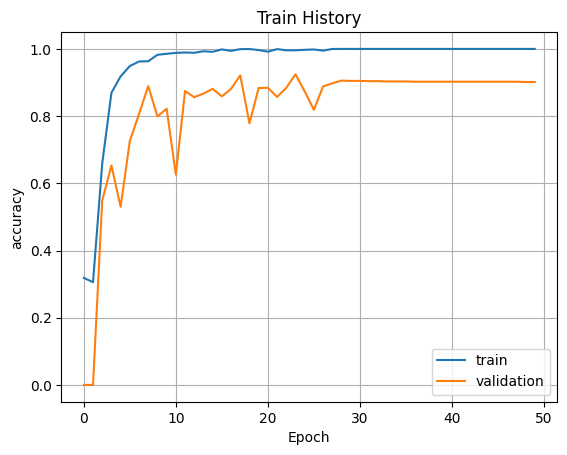

In [12]:
#繪製準確度之圖
import matplotlib.pyplot as plt

plt.plot(train_history.history['accuracy'])
plt.plot(train_history.history['val_accuracy'])
plt.title('Train History')  #主標題
plt.ylabel('accuracy')     #y軸名稱
plt.xlabel('Epoch')      #x軸名稱
plt.legend(['train', 'validation'], loc='lower right') #繪製圖例
plt.grid() #繪製網格
plt.savefig('Train_History_accuracy.png',dpi=300) #存圖，畫值取300dpi

plt.show()

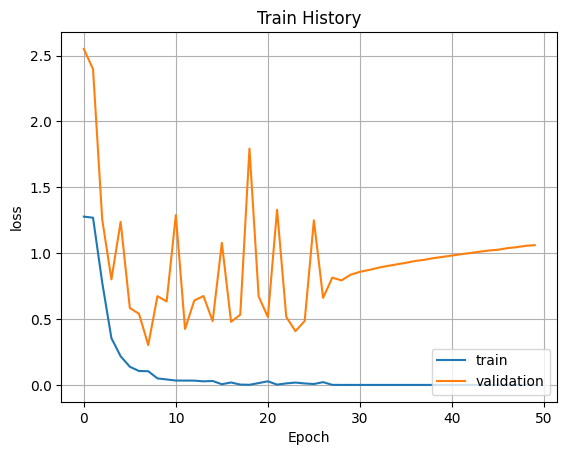

In [13]:
#繪製損失函數
plt.plot(train_history.history['loss'])
plt.plot(train_history.history['val_loss'])
plt.title('Train History')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.grid()
plt.savefig('Train_History_loss.png',dpi=300)

plt.show()

# Model prediction

In [14]:
#預測模型，放入x_test
prediction=model.predict(x_test) 
#classes_x=np.argmax(prediction,axis=1)
#計算損失函數與準確度
score = model.evaluate(x_test,y_test)

48/48 [==============================] - 6s 123ms/step - loss: 0.3515 - accuracy: 0.9619


# Confusion Matrix

In [ ]:
#建立混淆矩陣，分析模型好壞
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# print(y_test)
#改變y_test,y_pred的矩陣，用以分析模型好壞
y_test = np.argmax(y_test, axis=1)
y_pred = np.argmax(prediction,axis=1)

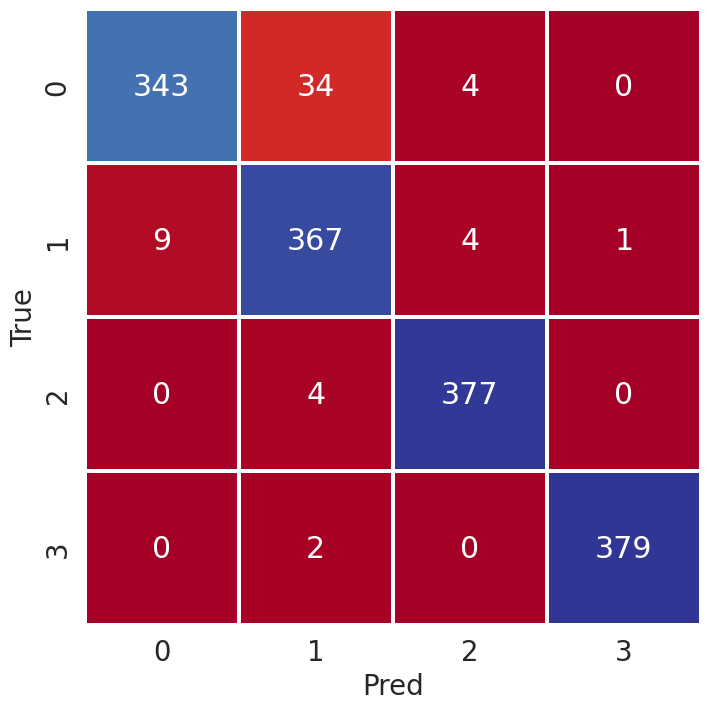

              precision    recall  f1-score   support

           0       0.97      0.90      0.94       381
           1       0.90      0.96      0.93       381
           2       0.98      0.99      0.98       381
           3       1.00      0.99      1.00       381

    accuracy                           0.96      1524
   macro avg       0.96      0.96      0.96      1524
weighted avg       0.96      0.96      0.96      1524



In [38]:
#繪製heatmap觀察預測與正確label差異
cm=confusion_matrix(y_test,y_pred)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,8))
sns.heatmap(cm,square=True,annot=True,fmt='d',linecolor='white',cmap='RdYlBu',linewidths=1.5,cbar=False)
sns.set(font_scale=5)
plt.xlabel('Pred',fontsize=20)
plt.ylabel('True',fontsize=20)
plt.show()

print(classification_report(y_test,y_pred))